# Task 1 — Character-level GPT from scratch on TinyStories (Chaitanya)

This notebook loads the artifacts produced by the scripts in this folder and shows them with outputs. Training itself is run with `train.py` (about 2 h on an RTX 4090), not inside the notebook.

| Step | Command |
|---|---|
| Preprocess | `python task1_llm/member_chaitanya/src/preprocess.py --config task1_llm/member_chaitanya/configs/full.yaml` |
| Train | `python task1_llm/member_chaitanya/src/train.py --config task1_llm/member_chaitanya/configs/full.yaml` |
| Evaluate | `python task1_llm/member_chaitanya/src/evaluate.py --config task1_llm/member_chaitanya/configs/full.yaml` |

In [1]:
import json, sys
from pathlib import Path

SRC = Path.cwd() if (Path.cwd() / 'model.py').exists() else Path('task1_llm/member_chaitanya/src').resolve()
sys.path.insert(0, str(SRC))
import numpy as np, pandas as pd, torch
from IPython.display import Image, display
from common import MEMBER_DIR, load_config, load_vocab, run_paths
from model import CharGPT
cfg = load_config('task1_llm/member_chaitanya/configs/full.yaml')
paths = run_paths(cfg['run_id'])
processed = paths['processed'] / cfg['data']['processed_name']
print(json.dumps({k: v for k, v in cfg.items() if not k.startswith('_')}, indent=1))

{
 "run_id": "full_run01",
 "seed": 1337,
 "data": {
  "dataset_name": "roneneldan/TinyStories",
  "text_field": "text",
  "cache_dir": "task1_llm/data/hf_cache",
  "processed_name": "tinystories_s1337_clean",
  "seed": 1337,
  "drop_stories_with_disallowed_chars": true,
  "allowed_extra_chars": [
   "\u201c",
   "\u201d"
  ],
  "train_stories": 100000,
  "val_stories": 10000,
  "eos_token": "<EOS>",
  "unk_token": "<UNK>",
  "block_size": 256,
  "train_stride": 128,
  "val_stride": 256
 },
 "model": {
  "n_layers": 6,
  "n_heads": 6,
  "d_model": 384,
  "d_ff": 1536,
  "dropout": 0.1,
  "activation": "gelu",
  "tie_weights": false,
  "bias": true
 },
 "training": {
  "epochs": 10,
  "batch_size": 64,
  "optimizer": "adamw",
  "betas": [
   0.9,
   0.99
  ],
  "weight_decay": 0.1,
  "peak_lr": 0.001,
  "warmup_steps": 1000,
  "min_lr": 0.0001,
  "grad_clip": 1.0,
  "precision": "fp32",
  "eval_every_steps": 1000,
  "eval_batches": 100,
  "log_every_steps": 50,
  "num_workers": 0
 },
 "

## 1.1 Data preprocessing
Cleaning statistics, story-level split, vocabulary (`char_to_idx` / `idx_to_char`).

In [2]:
meta = json.loads((processed / 'meta.json').read_text(encoding='utf-8'))
print(json.dumps({k: v for k, v in meta.items() if k != 'rare_chars_lt_100'}, indent=1))
char_to_idx, idx_to_char = load_vocab(processed)
print('vocab size:', len(char_to_idx))
print('characters:', ''.join(c for c in char_to_idx if len(c) == 1))

{
 "config": "task1_llm/member_chaitanya/configs/full.yaml",
 "seed": 1337,
 "cleaning": {
  "raw": 2119719,
  "missing_or_non_string": 0,
  "empty": 230,
  "disallowed_chars": 130139,
  "duplicates": 299039,
  "clean_unique": 1690311
 },
 "train_stories": 100000,
 "val_stories": 10000,
 "vocab_size": 85,
 "train_chars_incl_eos": 89654873,
 "val_chars_incl_eos": 9003962,
 "val_unk_chars": 0,
 "train_unk_chars": 0,
 "train_story_len_mean": 895.54873,
 "train_story_len_median": 782.0,
 "train_story_len_p95": 1765.0,
 "train_ids_sha256": "99151dfa1e75ccad9f6eb5bab9e508b1369353ba55edd1e9c5da766069841680",
 "val_ids_sha256": "0517a8619bf7a5fe0c77cc880dd69dbcaed91dfacd4672cf26dbd699522a9b4e"
}
vocab size: 85
characters: 
 !"$&'()*+,-./0123456789:;=?ABCDEFGHIJKLMNOPQRSTUVWXYZ\`abcdefghijklmnopqrstuvwxyz


In [3]:
from dataset import CharWindowDataset
train_ids = np.load(processed / 'train.npy')
ds = CharWindowDataset(train_ids, cfg['data']['block_size'], cfg['data']['train_stride'])
x, y = ds[0]
dec = lambda t: ''.join(idx_to_char[int(i)] for i in t)
print('windows:', len(ds))
print('input :', repr(dec(x[:80])))
print('target:', repr(dec(y[:80])))

windows: 700427
input : 'Once upon a time, there was a mommy and her baby. Mommy was doing chores around '
target: 'nce upon a time, there was a mommy and her baby. Mommy was doing chores around t'


## 1.2 Model
Pre-LN Transformer blocks written from scratch (`model.py`).

In [4]:
model = CharGPT(cfg['model'], len(char_to_idx), cfg['data']['block_size'])
print(model)
print(f'parameters: {model.num_params():,}')

CharGPT(
  (tok_emb): Embedding(85, 384)
  (pos_emb): Embedding(256, 384)
  (emb_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (ln_attn): LayerNorm()
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_ffn): LayerNorm()
      (ffn): FeedForward(
        (fc_in): Linear(in_features=384, out_features=1536, bias=True)
        (fc_out): Linear(in_features=1536, out_features=384, bias=True)
        (act): GELU(approximate='none')
      )
      (resid_dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (ln_final): LayerNorm()
  (lm_head): Linear(in_features=384, out_features=85, bias=False)
)
parameters: 10,811,136


In [5]:
# causal mask check: changing characters after position p must not change outputs at positions <= p
model.eval(); seq = x.unsqueeze(0); p = 100
alt = seq.clone(); alt[:, p + 1:] = (alt[:, p + 1:] + 1) % len(char_to_idx)
with torch.no_grad():
    a, _ = model(seq); b, _ = model(alt)
print('outputs up to p unchanged:', torch.allclose(a[:, :p + 1], b[:, :p + 1], atol=1e-5))
print('outputs after p changed  :', not torch.allclose(a[:, p + 1:], b[:, p + 1:]))

outputs up to p unchanged: True
outputs after p changed  : True


## 1.3 Training and generation

In [6]:
print(json.dumps(json.loads((paths['outputs'] / 'train_summary.json').read_text()), indent=1))
pd.DataFrame(json.loads((paths['outputs'] / 'history.json').read_text())['epochs'])

{
 "run_id": "full_run01",
 "param_count": 10811136,
 "vocab_size": 85,
 "train_windows": 700427,
 "total_steps": 109440,
 "epochs": 10,
 "total_train_time_s": 8457.795989899896,
 "train_compute_time_s": 7617.59502717969,
 "train_tokens_per_sec": 235384.65271549855,
 "peak_memory_mb": 4598.45458984375,
 "max_grad_norm": 9.627074241638184,
 "mean_grad_norm": 0.20079960554663898,
 "loss_spikes": 0,
 "spike_rule": "step loss > 1.5 x mean of previous 100 step losses (after warm-up)",
 "nan_count": 0,
 "best_val_loss": 0.5096606620763791,
 "hardware": "GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
}


,epoch,step,train_loss_running_mean,train_loss_eval,val_loss,val_acc,elapsed_s
0,1,10944,0.807609,0.621700,0.627145,0.799820,851.963447
1,2,21888,0.630332,0.587772,0.595263,0.809706,1696.426338
2,3,32832,0.605910,0.568857,0.577684,0.814993,2541.048799
3,4,43776,0.589445,0.554509,0.565070,0.818821,3384.747389
4,5,54720,0.574834,0.541790,0.554362,0.822224,4229.585212
5,6,65664,0.560960,0.526818,0.541207,0.825865,5074.146544
6,7,76608,0.547089,0.514070,0.531707,0.829175,5923.274308
7,8,87552,0.533582,0.499861,0.520143,0.832282,6768.289503
8,9,98496,0.521534,0.489458,0.512879,0.834638,7612.856771
9,10,109440,0.513431,0.484038,0.509661,0.835848,8457.702929


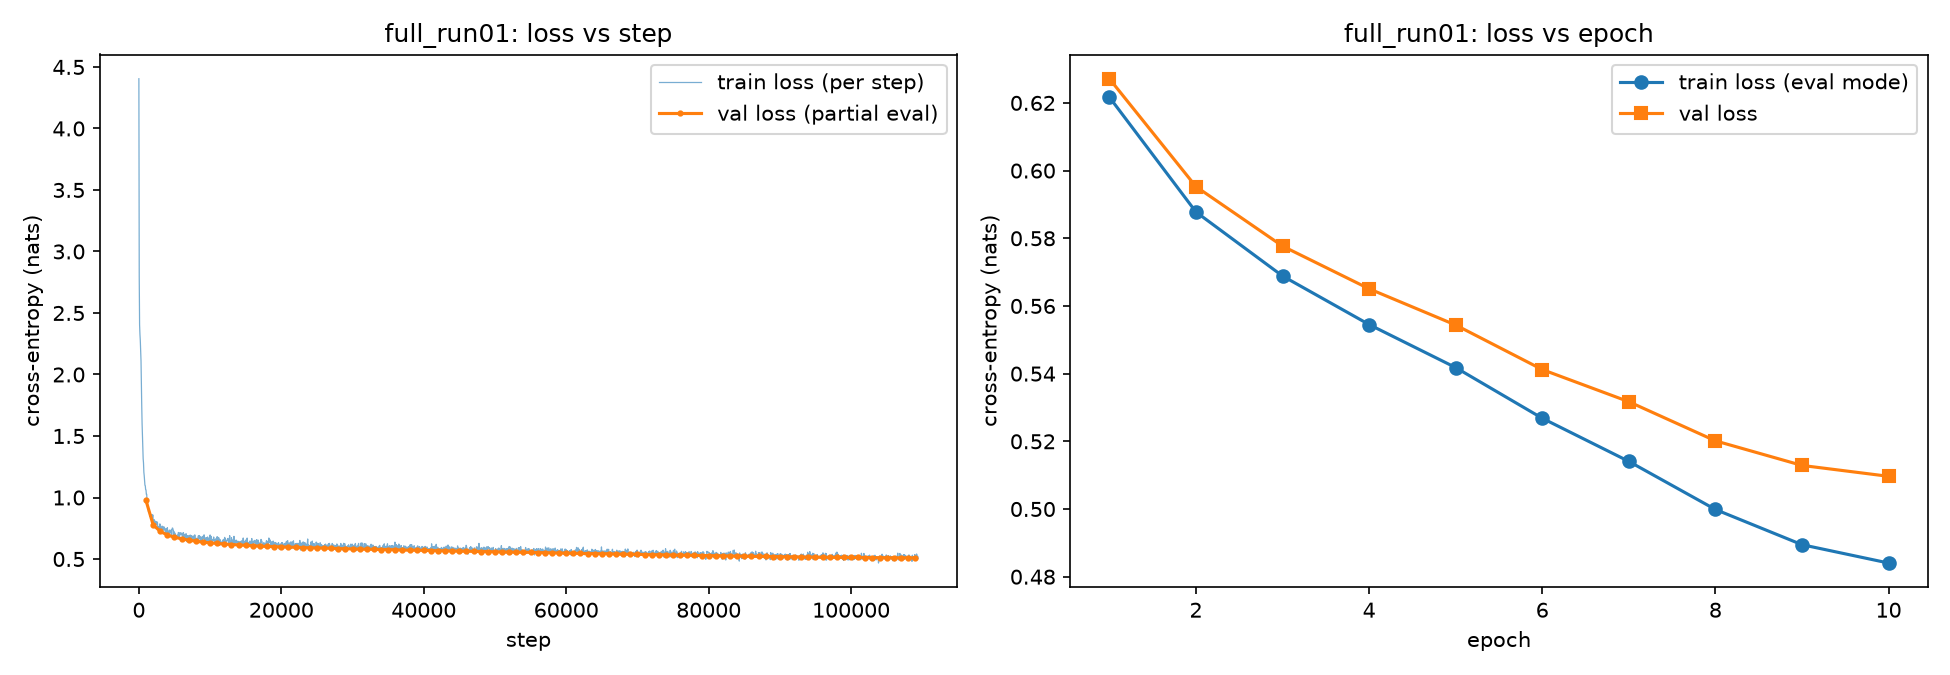

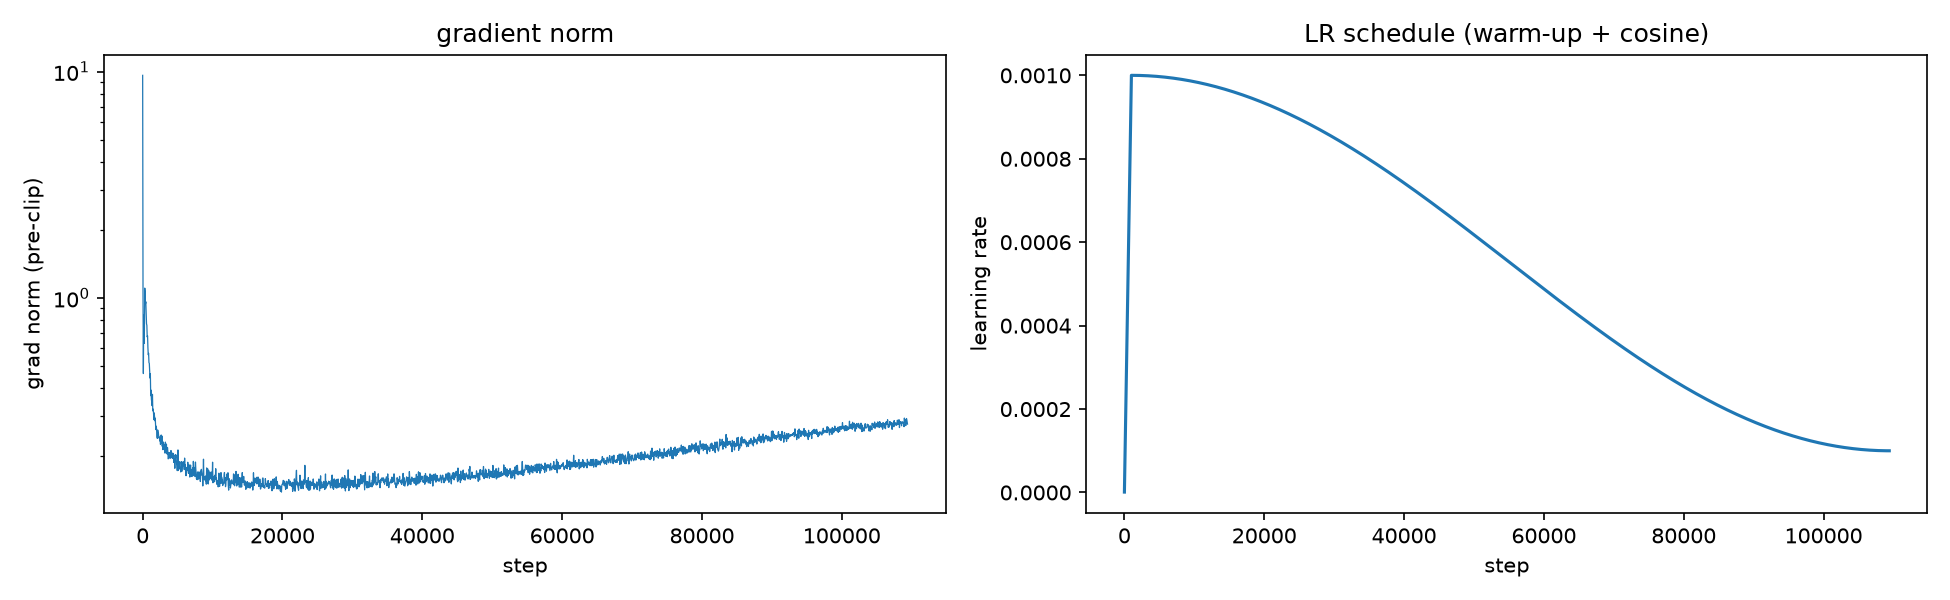

In [7]:
display(Image(str(paths['outputs'] / 'loss_curves.png')))
display(Image(str(paths['outputs'] / 'stability.png')))

In [8]:
print((paths['outputs'] / 'samples.txt').read_text(encoding='utf-8'))

=== greedy | prompt: 'Once upon a time' | sample 0 | ended_with_eos=False ===
Once upon a time, there was a little girl named Lily. She loved to play with her toys and her favorite was a big box. One day, Lily's mom asked her to clean up her toys and put them away. Lily didn't want to clean up, but her mom said she had to wait until she was done. 

Lily was sad because she wanted to play with her toys and her friends. She went to her room and sat down on her bed. She felt sad that her toys

=== greedy | prompt: 'Lily found a little' | sample 0 | ended_with_eos=False ===
Lily found a little box of toys and she wanted to play with them. She asked her mom if she could play with them, but her mom said no. Lily was sad and didn't know what to do.

Later that day, Lily went to the park with her mom. She saw a boy who was sad because she was sad because she lost her toy. He wanted to help her find it. So, Lily went to the boy and asked for help. The boy was still sad because he lost his t

==

## Metrics

In [9]:
pd.set_option('display.max_columns', None)
display(pd.read_csv(MEMBER_DIR / 'metrics_report.csv').T)
pd.read_csv(paths['outputs'] / 'generation_metrics.csv')

,0
run_id,full_run01
checkpoint,"checkpoints/full_run01/final.pt (epoch 10, ste..."
train_ce_loss,0.484174
val_ce_loss,0.509661
perplexity,1.664726
bits_per_char,0.735285
generalization_gap,0.025486
top1_next_char_acc,0.835848
distinct_1,0.344311
distinct_2,0.778452


,temperature,num_samples,distinct_1,distinct_2,distinct_3,repeated_4gram_rate
0,0.0,3,0.387097,0.738776,0.880165,0.033363
1,0.8,9,0.344311,0.778452,0.929231,0.019538
2,1.0,9,0.404255,0.881356,0.987500,0.000000
